Import các thư viện cần thiết

In [18]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Thêm thư mục cha (L02) vào sys.path
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

from src.data_processing import load_csv
from src.visualization import visua_hist, visua_boxplot, visua_scatter

# Đọc dữ liệu và cho dữ liệu có số hàng số cột (Load data)

In [3]:
DATA_PATH = "../data/raw/BankChurners.csv"
data, header = load_csv(DATA_PATH)

print("Shape:", data.shape)
print("Header:", header)
print("First row:", data[0])

Shape: (10127, 23)
Header: ['"CLIENTNUM"', '"Attrition_Flag"', '"Customer_Age"', '"Gender"', '"Dependent_count"', '"Education_Level"', '"Marital_Status"', '"Income_Category"', '"Card_Category"', '"Months_on_book"', '"Total_Relationship_Count"', '"Months_Inactive_12_mon"', '"Contacts_Count_12_mon"', '"Credit_Limit"', '"Total_Revolving_Bal"', '"Avg_Open_To_Buy"', '"Total_Amt_Chng_Q4_Q1"', '"Total_Trans_Amt"', '"Total_Trans_Ct"', '"Total_Ct_Chng_Q4_Q1"', '"Avg_Utilization_Ratio"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"']
First row: ['768805383' '"Existing Customer"' '45' '"M"' '3' '"High School"'
 '"Married"' '"$60K - $80K"' '"Blue"' '39' '5' '1' '3' '12691' '777'
 '11914' '1.335' '1144' '42' '1.625' '0.061' '9.3448e-05' '0.99991']


# Kiểm tra giá trị thiếu (missing value)

In [4]:
missing_mask = (data == '') | (data == 'NaN') | (data == 'nan') | (data == '?')
missing_counts = np.sum(missing_mask, axis=0)

for col_name, count in zip(header, missing_counts):
    print(f"{col_name}: {count}")


"CLIENTNUM": 0
"Attrition_Flag": 0
"Customer_Age": 0
"Gender": 0
"Dependent_count": 0
"Education_Level": 0
"Marital_Status": 0
"Income_Category": 0
"Card_Category": 0
"Months_on_book": 0
"Total_Relationship_Count": 0
"Months_Inactive_12_mon": 0
"Contacts_Count_12_mon": 0
"Credit_Limit": 0
"Total_Revolving_Bal": 0
"Avg_Open_To_Buy": 0
"Total_Amt_Chng_Q4_Q1": 0
"Total_Trans_Amt": 0
"Total_Trans_Ct": 0
"Total_Ct_Chng_Q4_Q1": 0
"Avg_Utilization_Ratio": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2": 0


# Xem số giá trị duy nhất của từng đặc trưng (Categorical Analysis)

In [12]:
for i in range(data.shape[1]):
    uni_i = np.unique(data[:, i])
    print(header[i], " - Count unique:", len(uni_i))
    print("- Example: ",uni_i[:2])

"CLIENTNUM"  - Count unique: 10127
- Example:  ['708082083' '708083283']
"Attrition_Flag"  - Count unique: 2
- Example:  ['"Attrited Customer"' '"Existing Customer"']
"Customer_Age"  - Count unique: 45
- Example:  ['26' '27']
"Gender"  - Count unique: 2
- Example:  ['"F"' '"M"']
"Dependent_count"  - Count unique: 6
- Example:  ['0' '1']
"Education_Level"  - Count unique: 7
- Example:  ['"College"' '"Doctorate"']
"Marital_Status"  - Count unique: 4
- Example:  ['"Divorced"' '"Married"']
"Income_Category"  - Count unique: 6
- Example:  ['"$120K +"' '"$40K - $60K"']
"Card_Category"  - Count unique: 4
- Example:  ['"Blue"' '"Gold"']
"Months_on_book"  - Count unique: 44
- Example:  ['13' '14']
"Total_Relationship_Count"  - Count unique: 6
- Example:  ['1' '2']
"Months_Inactive_12_mon"  - Count unique: 7
- Example:  ['0' '1']
"Contacts_Count_12_mon"  - Count unique: 7
- Example:  ['0' '1']
"Credit_Limit"  - Count unique: 6205
- Example:  ['10001' '10007']
"Total_Revolving_Bal"  - Count uniqu

# Vẽ biểu đồ Histogram cho các cột (dữ liệu số) để thấy sự phân bố tần số của chúng

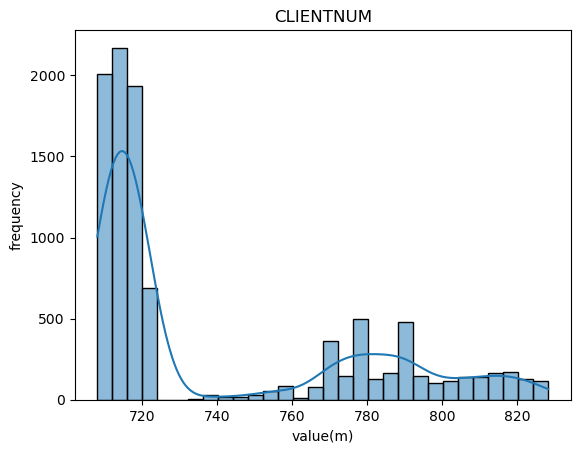

In [ ]:
CLIENTNUM = data[:,0].astype(int)
visua_hist(CLIENTNUM/1e6, "CLIENTNUM Distribution", "CLIENTNUM (m)", "Frequency")

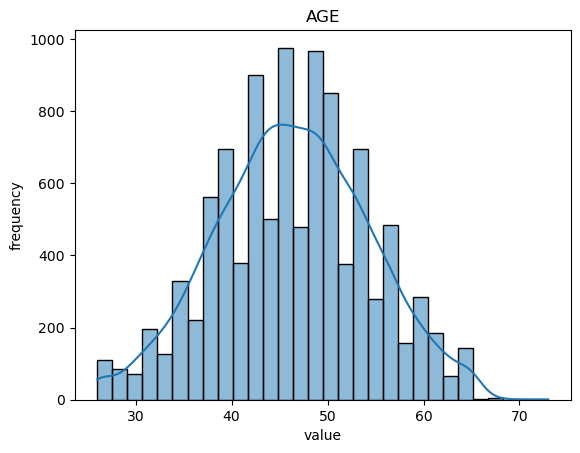

In [6]:
Customer_Age = data[:,2].astype(int)
visua_hist(Customer_Age, "AGE", "value", "frequency")

# Vẽ biểu đồ bar chart thể hiện giá trị dữ liệu và tần suất xuất hiện của chúng

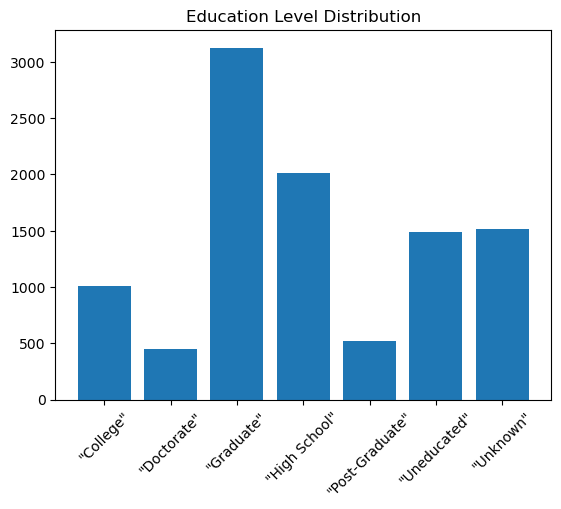

In [19]:

# Example: Education Level
edu_idx = header.index('"Education_Level"')
unique_edu, edu_counts = np.unique(data[:, edu_idx], return_counts=True)

plt.figure()
plt.bar(unique_edu, edu_counts)
plt.xticks(rotation=45)
plt.title("Education Level Distribution")
plt.show()

Vẽ biều đồ Scatter để phân tích mối liên hệ giữa các đặc trưng

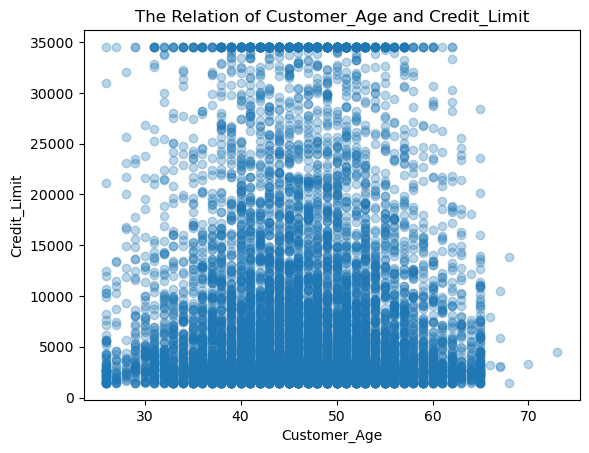

In [7]:
# Customer_Age và Credit_Limit
Credit_Limit = data[:,13].astype(float)
visua_scatter(Customer_Age, Credit_Limit, "The Relation of Customer_Age and Credit_Limit", "Customer_Age", "Credit_Limit")

In [8]:
# Total_Trans_Amt và Total_Trans_Ct